In [1]:
### Installing dependencies

import mesa
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid

### Creating the Agents



class BaseCell(CellAgent):

  """
  The BaseCell class represents any cell in the simulation with the following attributes:
  pos - position of the cell
  health - the health of the cell
  """

  def __init__(self, model, cell, health=1.0):
    super().__init__(model)
    self.cell = cell
    self.health = health

class TumourCell(BaseCell):

  """
  The TumourCell class represents all tumour cells:
  antigen - the level of surface antigen that the ImmuneCell class can recognise (1-9)
  """

  def __init__(self, model, cell, health=1.0, antigen=9):
    super().__init__(model, cell, health)
    self.antigen = antigen

  def die(self):
    self.remove()

  def proliferate(self, p_proliferate=0.1, p_mutation=0.15):
    if self.random.random() < p_proliferate:
      neighbor = self.cell.neighborhood.select_random_cell()
      if not any(isinstance(a, TumourCell) for a in neighbor.agents):
        daughter_antigen = self.antigen
        if self.random.random() < p_mutation:
          daughter_antigen = max(1, min(9, self.antigen + self.random.choice([-1, 1])))
        TumourCell(self.model, neighbor, antigen=daughter_antigen)

  def step(self):
    self.proliferate()

class ImmuneCell(BaseCell):

  """
  An ImmuneCell class that represents cells of the immune system with the ability to kill TumourCell agents.
  Migrates preferentially towards killable tumour cells (antigen > 2) within a 2-cell radius (chemotaxis).
  """

  def __init__(self, model, cell, health=1.0):
    super().__init__(model, cell, health)

  def _chebyshev(self, c1, c2):
    x1, y1 = c1.coordinate
    x2, y2 = c2.coordinate
    return max(abs(x1 - x2), abs(y1 - y2))

  def move(self):
    neighbors = [c for c in self.cell.neighborhood.cells if c is not self.cell]

    nearby_killable = [
        a for a in self.model.agents_by_type[TumourCell]
        if a.antigen > 2 and self._chebyshev(self.cell, a.cell) <= 2
    ]

    if nearby_killable:
      target = min(nearby_killable, key=lambda a: self._chebyshev(self.cell, a.cell))
      min_dist = min(self._chebyshev(c, target.cell) for c in neighbors)
      best = [c for c in neighbors if self._chebyshev(c, target.cell) == min_dist]
      self.cell = self.random.choice(best)
    else:
      self.cell = self.random.choice(neighbors)

  def kill(self):
    cellmates = [a for a in self.cell.agents if a is not self]

    if cellmates:
      target_tumour_cells = [a for a in cellmates if isinstance(a, TumourCell) and a.antigen > 2]

      if target_tumour_cells:
        target = self.random.choice(target_tumour_cells)
        target.health -= 1
        if target.health <= 0:
          target.die()

  def step(self):
    self.move()
    self.kill()

In [2]:
class EvasionModel(Model):
  def __init__(self, *, n_tumour=30, n_immune=10, width=10, height=10):
    super().__init__()

    self.grid = OrthogonalMooreGrid(
        (width, height), torus=True, random=self.random
    )

    # Place tumour cells on distinct empty cells, all starting with high antigen (3-9)
    empty_cells = list(self.grid.all_cells.cells)
    self.random.shuffle(empty_cells)
    for cell in empty_cells[:n_tumour]:
      TumourCell(self, cell, antigen=self.random.randint(2, 9))

    # Place immune cells — no occupancy restriction
    for _ in range(n_immune):
      cell = self.grid.all_cells.select_random_cell()
      ImmuneCell(self, cell)

    for agent in self.agents:
      assert agent.cell is not None, f'Agent {agent.unique_id} has no cell'

    antigen_reporters = {
        f"Antigen_{i}": (lambda m, i=i: len(m.agents_by_type[TumourCell].select(lambda a: a.antigen == i)))
        for i in range(1, 10)
    }

    self.datacollector = DataCollector(
        model_reporters={
            "TumourCells": lambda m: len(m.agents_by_type[TumourCell]),
            "ImmuneCells": lambda m: len(m.agents_by_type[ImmuneCell]),
            **antigen_reporters,
        },
    )
    self.datacollector.collect(self)

  def step(self):
    self.agents.shuffle_do('step')
    self.datacollector.collect(self)

<Axes: >

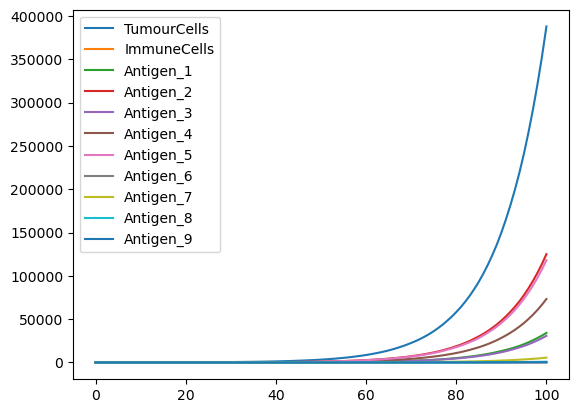

In [13]:
### Batch run (optional — run independently to inspect without the dashboard)

model = EvasionModel(n_tumour=50, n_immune=10, width=10, height=10)

for _ in range(100):
    model.step()

df = model.datacollector.get_model_vars_dataframe()
df.plot()

In [3]:
from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa.visualization.components import AgentPortrayalStyle


antigen_colors = {
    1: "#fce4ec",
    2: "#f8bbd0",
    3: "#f48fb1",
    4: "#f06292",
    5: "#ec407a",
    6: "#e91e63",
    7: "#c2185b",
    8: "#ad1457",
    9: "#880e4f",
}

def agent_portrayal(agent):
    if isinstance(agent, TumourCell):
        return AgentPortrayalStyle(color=antigen_colors[agent.antigen], size=40)
    elif isinstance(agent, ImmuneCell):
        return AgentPortrayalStyle(color="tab:blue", size=40)


model_params = {
    "n_tumour": {
        "type": "SliderInt",
        "value": 30,
        "label": "Number of tumour cells:",
        "min": 10,
        "max": 50,
        "step": 1,
    },
    "n_immune": {
        "type": "SliderInt",
        "value": 10,
        "label": "Number of immune cells:",
        "min": 1,
        "max": 25,
        "step": 1,
    },
    "width": 20,
    "height": 20,
}

evasion_model = EvasionModel(n_tumour=30, n_immune=10, width=20, height=20)

renderer = (
    SpaceRenderer(model=evasion_model, backend="matplotlib")
    .setup_agents(agent_portrayal)
    .render()
)

PopulationPlot = make_plot_component(
    {"TumourCells": "tab:red", "ImmuneCells": "tab:blue"},
    page=1,
)

AntigenPlot = make_plot_component(
    {f"Antigen_{i}": antigen_colors[i] for i in range(1, 10)},
    page=2,
)

Page = SolaraViz(
    evasion_model,
    renderer,
    components=[PopulationPlot, AntigenPlot],
    model_params=model_params,
    name="Tumour-Immune Evasion Model",
)
Page

Cannot show ipywidgets in text